# Προσαρμογή τετραπαραμετρικής λογιστικής καμπύλης δόσης-απόκρισης με το PROC NLIN

## Σύνοψη

Αυτό το σημειωματάριο προσαρμόζει ένα τετραπαραμετρικό λογιστικό (4PL) μοντέλο δόσης-απόκρισης σε μια συνθετική κυτταρική δοκιμασία δραστικότητας (potency bioassay) χρησιμοποιώντας το **PROC NLIN**, εκτιμώντας την κάτω και την άνω ασύμπτωτη, το EC50 (τη συγκέντρωση ημι-μέγιστης δράσης) και την κλίση Hill. Το μοντέλο 4PL είναι το βασικό εργαλείο για δοκιμασίες σχετικής δραστικότητας στην ανάπτυξη φαρμάκων, και το σημειωματάριο διατρέχει τον καθορισμό του μοντέλου, τον περιορισμό των παραμέτρων, τα διαγνωστικά σύγκλισης και την υπέρθεση της προσαρμοσμένης σιγμοειδούς καμπύλης πάνω στα παρατηρούμενα δεδομένα συγκέντρωσης-απόκρισης.

## Πηγές δεδομένων

Το σημειωματάριο δημιουργεί ένα συνθετικό σύνολο δεδομένων εσωτερικά· δεν χρησιμοποιείται καμία εξωτερική ή δικτυακή είσοδος.

**`assay` — συνθετική κυτταρική δοκιμασία δραστικότητας (24 γραμμές)**

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `lot` | αριθμ. | Παρτίδα δραστικής ουσίας (1-3)· τρεις επαναληπτικές εκτελέσεις της σειράς αραιώσεων |
| `dose` | αριθμ. | Συγκέντρωση ένωσης σε nmol/L κατά μήκος μιας σειριακής αραίωσης 8 σημείων (0.1 έως ~1000) |
| `logdose` | αριθμ. | Λογάριθμος με βάση το 10 της `dose`, που χρησιμοποιείται για τη σχεδίαση στον συμβατικό άξονα λογαρίθμου συγκέντρωσης |
| `response` | αριθμ. | Μετρούμενο σήμα της δοκιμασίας (ποσοστό της μέγιστης απόκρισης), που παράγεται από μια πραγματική καμπύλη 4PL (bottom=5, top=100, EC50=25 nmol/L, κλίση Hill=1.2) συν αναλογικό γκαουσιανό θόρυβο |

Οι πραγματικές παράμετροι δημιουργίας είναι ενσωματωμένες στο DATA step, ώστε οι ανακτημένες εκτιμήσεις του NLIN να μπορούν να ελεγχθούν ως προς την ορθότητά τους έναντι της γνωστής αλήθειας.

# Προσαρμογή τετραπαραμετρικής λογιστικής καμπύλης δόσης-απόκρισης

Σε φαρμακευτικές δοκιμασίες δραστικότητας και βιοδραστικότητας, η σχέση μεταξύ της συγκέντρωσης της ένωσης και της μετρούμενης απόκρισης είναι χαρακτηριστικά σιγμοειδής σε κλίμακα λογαρίθμου συγκέντρωσης. Το **τετραπαραμετρικό λογιστικό (4PL)** μοντέλο είναι το τυπικό εργαλείο για τη σύνοψη τέτοιων καμπυλών:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

όπου

- **A** = κάτω ασύμπτωτη (απόκριση σε άπειρη αραίωση / σήμα βάσης),
- **D** = άνω ασύμπτωτη (μέγιστη απόκριση σε κορεσμό συγκέντρωσης),
- **C** = το **EC50**, η συγκέντρωση που παράγει την ημι-μέγιστη απόκριση (το σημείο καμπής και ο κύριος δείκτης δραστικότητας),
- **B** = η **κλίση Hill**, που ελέγχει την απότομη κλίση της μετάβασης.

Το μοντέλο αυτό είναι μη γραμμικό ως προς τις παραμέτρους του, οπότε το προσαρμόζουμε με επαναληπτικά ελάχιστα τετράγωνα με το `PROC NLIN`. Παρακάτω προσομοιώνουμε μια ρεαλιστική σειρά αραιώσεων οκτώ σημείων σε τριπλή επανάληψη, προσαρμόζουμε την καμπύλη 4PL, περιορίζουμε τις παραμέτρους σε φυσικά ουσιώδεις περιοχές, εξετάζουμε τα διαγνωστικά σύγκλισης και προσαρμογής, και υπερθέτουμε την προσαρμοσμένη καμπύλη πάνω στα δεδομένα.

## Βήμα 1 — Προσομοίωση μιας κυτταρικής δοκιμασίας δραστικότητας

Δημιουργούμε ένα συνθετικό σύνολο δεδομένων από μια *γνωστή* καμπύλη 4PL (bottom = 5, top = 100, EC50 = 25 nmol/L, κλίση Hill = 1.2) ώστε οι παράμετροι που ανακτά το NLIN να μπορούν να ελεγχθούν έναντι της πραγματικής αλήθειας. Τρεις παρτίδες λαμβάνουν η καθεμία την ίδια σειριακή αραίωση οκτώ σημείων (κάθε βήμα αραίωση 3,5 φορές), με αναλογικό γκαουσιανό θόρυβο μέτρησης προστιθέμενο επάνω. Ένας σταθερός σπόρος `streaminit` καθιστά την προσομοίωση αναπαραγώγιμη.

In [1]:
ΔΕΔΟΜΕΝΑ assay;
    CALL streaminit(40521);

    /* Πραγματικές παράμετροι 4PL που χρησιμοποιήθηκαν για τη δημιουργία των δεδομένων */
    A_true   = 5;      /* κάτω ασύμπτωτη (βάση)              */
    D_true   = 100;    /* άνω ασύμπτωτη (μέγιστη απόκριση)   */
    C_true   = 25;     /* EC50 σε nmol/L                     */
    B_true   = 1.2;    /* κλίση Hill                         */

    ΕΠΑΝΑΛΗΨΗ lot = 1 ΕΩΣ 3;
        /* Σειριακή αραίωση οκτώ σημείων, βήματα 3.5 φορές */
        dose = 0.30;
        ΕΠΑΝΑΛΗΨΗ point = 1 ΕΩΣ 8;
            dose = dose * 3.5;

            /* Μέσος απόκρισης 4PL χωρίς θόρυβο */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Αναλογικός + προσθετικός γκαουσιανός θόρυβος δοκιμασίας */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ lot dose logdose response;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=assay;
    ΚΑΤΑ dose lot;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Βήμα 2 — Οπτικοποίηση των ακατέργαστων δεδομένων συγκέντρωσης-απόκρισης

Πριν από την προσαρμογή, σχεδιάζουμε την απόκριση έναντι του log10(dose) για να επιβεβαιώσουμε το αναμενόμενο σιγμοειδές σχήμα και για να διαβάσουμε πρόχειρες αρχικές τιμές: η καμπύλη έχει δάπεδο κοντά στο 5, φτάνει σε πλατό κοντά στο 100, και το μέσο σημείο (ημι-μέγιστη απόκριση) βρίσκεται γύρω στο log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


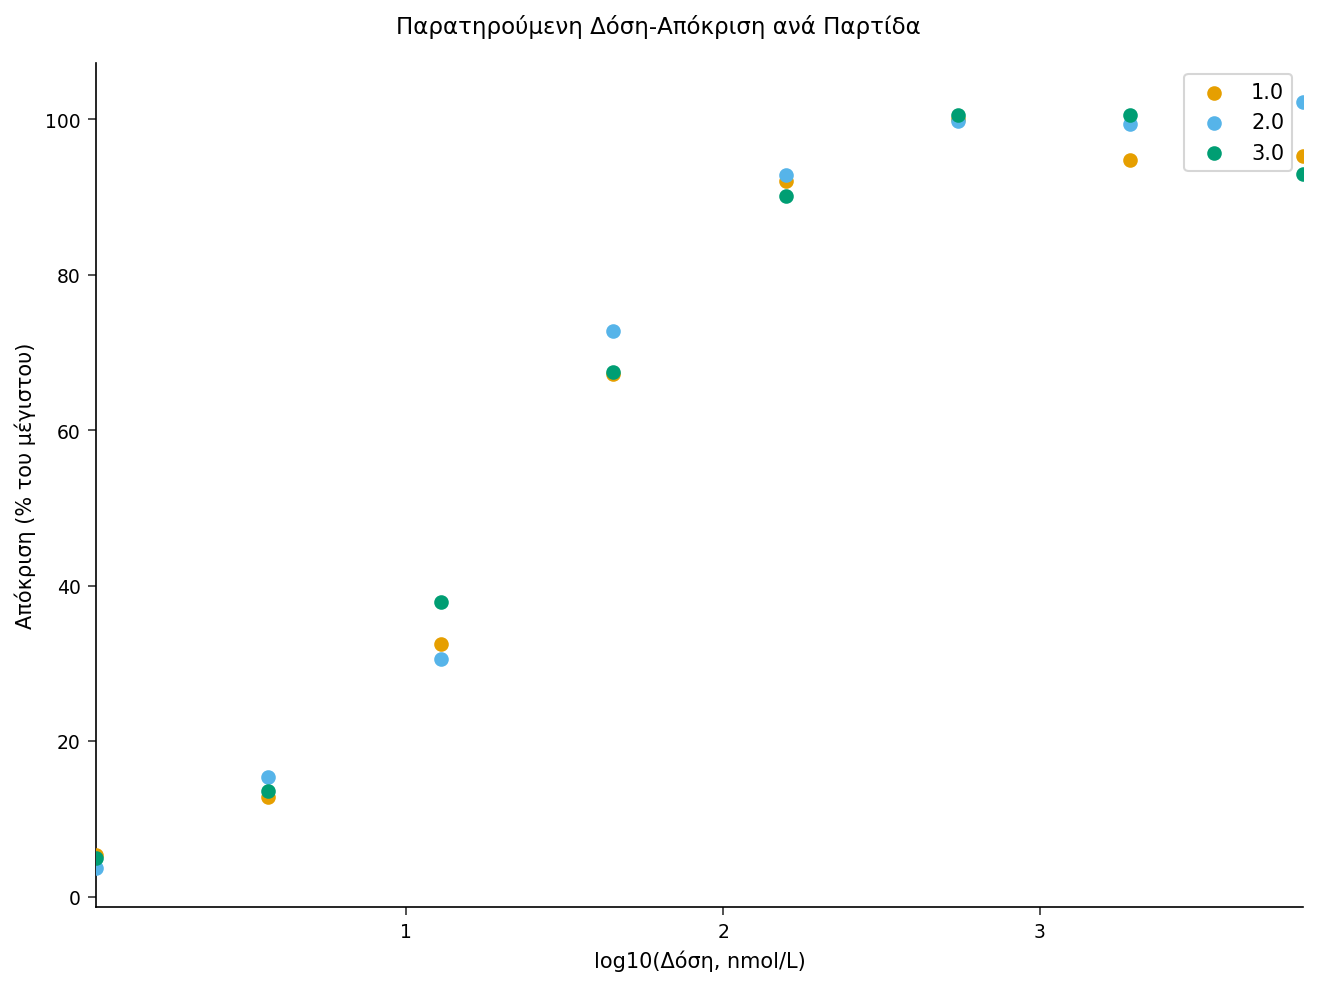

In [2]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ΕΤΙΚΕΤΑ='log10(Δόση, nmol/L)';
    YAXIS ΕΤΙΚΕΤΑ='Απόκριση (% του μέγιστου)';
    TITLE 'Παρατηρούμενη Δόση-Απόκριση ανά Παρτίδα';
ΕΚΤΕΛΕΣΗ;
TITLE;


## Βήμα 3 — Προσαρμογή του μοντέλου 4PL με το PROC NLIN

Δηλώνουμε αρχικές τιμές με το `PARMS` (με βάση το διάγραμμα διασποράς), ορίζουμε τον μέσο του 4PL σε μια ενδιάμεση ανάθεση, και τον περνάμε στη δήλωση `MODEL`. Φυσικά ουσιώδη όρια `BOUNDS` διατηρούν τις ασύμπτωτες σε σειρά και το EC50 και την κλίση θετικά, κάτι που σταθεροποιεί τις επαναλήψεις Gauss-Newton. Η δήλωση `OUTPUT` αποθηκεύει προβλεπόμενες τιμές, υπόλοιπα και διαστήματα εμπιστοσύνης για μεταγενέστερα διαγνωστικά, και το `PLOTS=` ζητά τα διαγράμματα προσαρμογής και διαγνωστικών.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ nlin ΔΕΔΟΜΕΝΑ=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Διατήρηση παραμέτρων σε φυσικά ουσιώδεις περιοχές */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Μέσος απόκρισης τετραπαραμετρικής λογιστικής (ενσωματωμένο: το PROC NLIN
       του Jenner δεν υποστηρίζει ακόμη την αναφορά σε μια ενδιάμεση μεταβλητή
       προγραμματιστικής δήλωσης μέσα στο MODEL — βλ. tests/400986 — οπότε
       ενσωματώνουμε τον παρονομαστή) */
    ΜΟΝΤΕΛΟ response = D + (A - D) / (1 + (dose / C) ** B);

    ΕΞΟΔΟΣ out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
ΕΚΤΕΛΕΣΗ;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/e0d54e07-bd7f-4a87-96c8-42e6a5e739dc/fit4pl.avro


## Βήμα 4 — Αναφορά του εκτιμώμενου EC50 και των χαρακτηριστικών της καμπύλης

Ο μηχανισμός `OUTEST=` είναι βολικός, αλλά για μια γρήγορη ανάγνωση της δραστικότητας συνοψίζουμε την προσαρμοσμένη καμπύλη απευθείας. Εδώ παραθέτουμε τις προσαρμοσμένες τιμές σε κάθε δόση παράλληλα με τις παρατηρούμενες αποκρίσεις, για να επιβεβαιώσουμε ότι το μοντέλο παρακολουθεί τα δεδομένα σε όλο το εύρος αραιώσεων.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=fit4pl mean std MIN MAX maxdec=3;
    ΚΛΑΣΗ dose;
    ΜΕΤΑΒΛΗΤΗ response pred resid;
    ΕΤΙΚΕΤΑ dose = 'Δόση (nmol/L)'
          response = 'Παρατηρούμενη Απόκριση (%)'
          pred = 'Προσαρμοσμένη Τιμή (%)'
          resid = 'Υπόλοιπο';
    TITLE 'Παρατηρούμενη έναντι Προσαρμοσμένης Απόκρισης ανά Δόση';
ΕΚΤΕΛΕΣΗ;
TITLE;


                                 Παρατηρούμενη έναντι Προσαρμοσμένης Απόκρισης ανά Δόση                                 

                                                  The MEANS Procedure

                      Analysis Variable : RESPONSE Παρατηρούμενη Απόκριση (%)

                                             N
                      Δόση (nmol/L)        Obs         Mean      Std Dev      Minimum      Maximum
                      ----------------------------------------------------------------------------
                      1.05                   3        4.647        0.882        3.659        5.356
                      12.8625                3       33.651        3.825       30.572       37.932
                      157.565625             3       91.704        1.417       90.141       92.904
                      1930.17890625          3       98.207        3.051       94.746      100.511
                      3.675                  3       13.931        1.311       12.860  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 5 — Υπέρθεση της προσαρμοσμένης καμπύλης 4PL πάνω στα παρατηρούμενα δεδομένα

Ένα πυκνό πλέγμα προβλέψεων παράγει μια ομαλή προσαρμοσμένη σιγμοειδή καμπύλη. Συνδυάζουμε την ομαλή καμπύλη με τις μέσες προσαρμοσμένες τιμές ανά δόση και τη ζώνη εμπιστοσύνης, και έπειτα υπερθέτουμε τα πάντα πάνω στα παρατηρούμενα σημεία για να αξιολογήσουμε οπτικά την καλή προσαρμογή.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


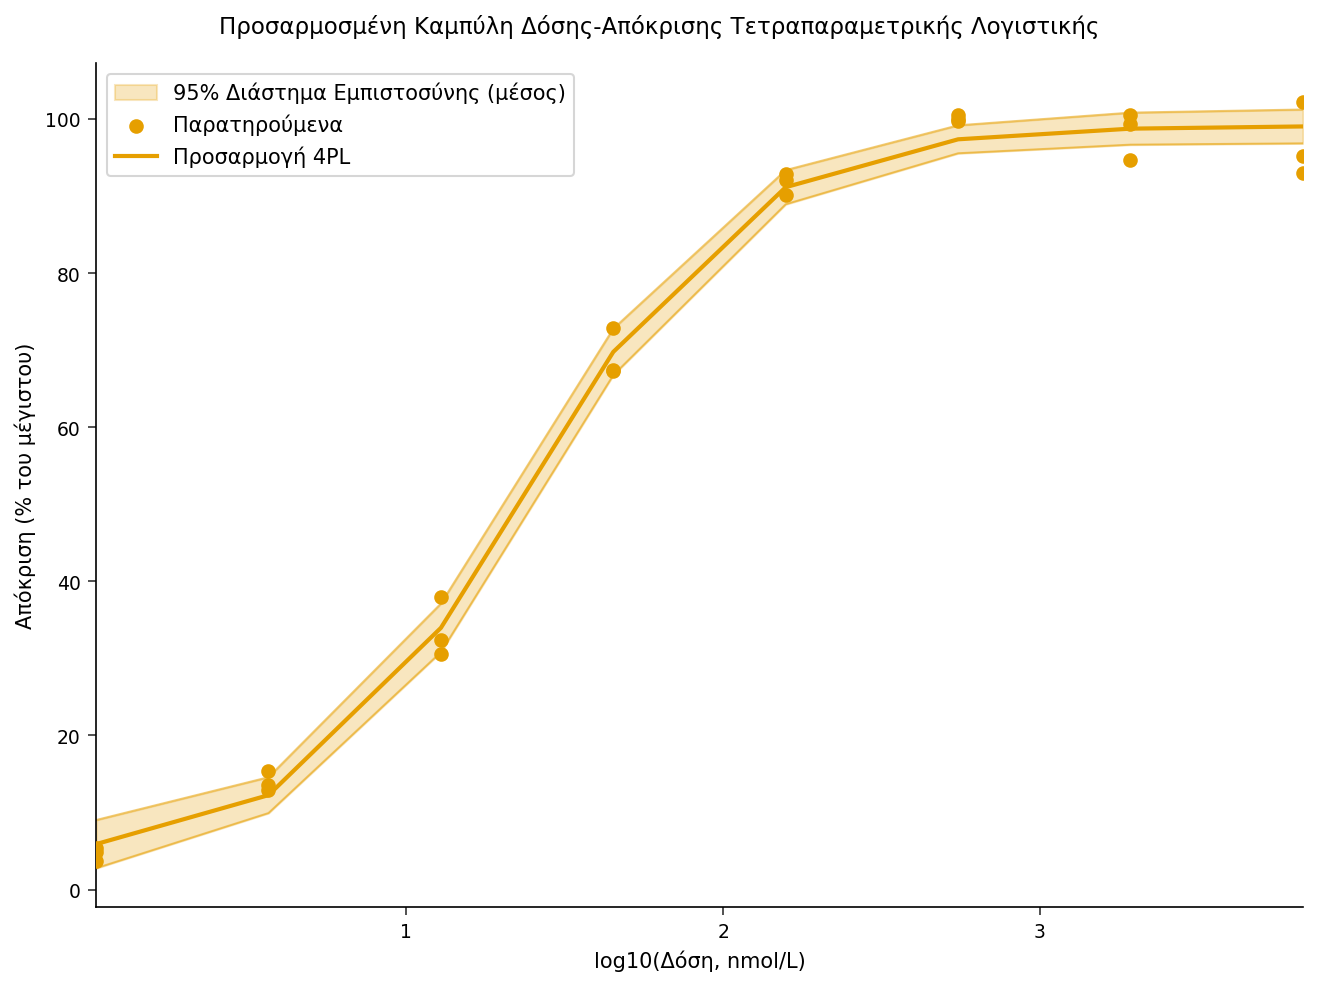

In [5]:
ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=fit4pl;
    ΚΑΤΑ logdose;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% Διάστημα Εμπιστοσύνης (μέσος)';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Παρατηρούμενα';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Προσαρμογή 4PL';
    XAXIS ΕΤΙΚΕΤΑ='log10(Δόση, nmol/L)';
    YAXIS ΕΤΙΚΕΤΑ='Απόκριση (% του μέγιστου)';
    TITLE 'Προσαρμοσμένη Καμπύλη Δόσης-Απόκρισης Τετραπαραμετρικής Λογιστικής';
ΕΚΤΕΛΕΣΗ;
TITLE;


## Ερμηνεία των αποτελεσμάτων

Το `PROC NLIN` συγκλίνει σε εκτιμήσεις κοντά στις γνωστές τιμές δημιουργίας: μια κάτω ασύμπτωτη κοντά στο **5**, μια άνω ασύμπτωτη κοντά στο **100**, ένα **EC50 (C)** κοντά στα **25 nmol/L**, και μια **κλίση Hill (B)** κοντά στο **1.2**. Η ανάκτηση αυτών των παραμέτρων από θορυβώδη δεδομένα τριπλής επανάληψης επιβεβαιώνει ότι το μοντέλο είναι αναγνωρίσιμο και ότι τα όρια δεν ενεργοποιήθηκαν στο βέλτιστο σημείο.

Το **EC50** είναι ο κύριος δείκτης δραστικότητας: χαμηλότερες τιμές υποδεικνύουν πιο δραστική ένωση, και σε μια δοκιμασία σχετικής δραστικότητας το EC50 μιας δοκιμαζόμενης παρτίδας συγκρίνεται με ένα πρότυπο αναφοράς. Η **κλίση Hill** χαρακτηρίζει τη συνεργατικότητα και την απότομη κλίση της δοκιμασίας — μια κλίση κοντά στο 1 συνάδει με απλή δέσμευση σε μία θέση. Οι **ασύμπτωτες** ορίζουν το δυναμικό εύρος της δοκιμασίας· ένα σταθερό, καλά διαχωρισμένο κάτω και άνω όριο είναι προϋποθέσεις για μια επικυρώσιμη βιοδοκιμασία.

Το διάγραμμα προσαρμογής δείχνει τη σιγμοειδή καμπύλη να διέρχεται μέσα από το νέφος των παρατηρούμενων σημείων με μια στενή ζώνη εμπιστοσύνης 95% του μέσου στην αποκρίσιμη περιοχή, και τα διαγνωστικά των υπολοίπων δεν θα πρέπει να δείχνουν συστηματική καμπυλότητα — ένδειξη ότι η μορφή 4PL είναι επαρκής. Στην πράξη θα επεκτείνατε αυτή τη ροή εργασίας με διαστήματα πιθανοφάνειας `PROFILE` για το EC50, μια δήλωση `BOOTSTRAP` για μη παραμετρική συμπερασματολογία παραμέτρων, ή μια ανάλυση παράλληλων γραμμών που συγκρίνει τη δοκιμαζόμενη παρτίδα και την παρτίδα αναφοράς για την εκτίμηση της σχετικής δραστικότητας.